# Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
import os
from pathlib import Path
import glob
from astropy.cosmology import FlatLambdaCDM
import h5py

# Jupyter plotting settings
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [15, 5]

In [2]:
# Add project root directory to make imports possible
root_dir = "/lustre/work/akira.tokiwa/Projects/LensingSSC"

project_root = Path(root_dir)
sys.path.append(str(project_root))

from lensing_ssc.utils.io import save_results_to_hdf5, load_results_from_hdf5
from lensing_ssc.core.fibonacci.fibonacci import FibonacciGrid
from lensing_ssc.core.fibonacci.optimizer import PatchOptimizer
from lensing_ssc.core.fibonacci.plotting import plot_coverage_map, plot_fibonacci_grid
from lensing_ssc.core.fibonacci.coverage import CoverageAnalyzer
from lensing_ssc.core.patch.statistics.analyzer import PatchAnalyzer

# Configuration

In [3]:
# Directory to save results
results_dir = project_root / "output" 
savedir = root_dir + "/output/figures"
os.makedirs(results_dir, exist_ok=True)

In [4]:
nside=512  # Healpix nside parameter
patch_size_deg = 10  # Patch size (degrees)
Ninit = 273  # Upper limit of initial patch count

In [5]:
zs_list = [0.5, 1.0, 1.5, 2.0, 2.5]
ngal_list = [0, 7, 15, 30, 50]
sl_list = [2, 5, 8, 10]
box_types = ["bigbox", "tiled"]
stats_name = ['power_spectra', 'equilateral', 'isosceles', 'squeezed', 'pdf', 'peaks', 'minima','v0', 'v1', 'v2']

In [6]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
survey_info = {
    '0': 'Noiseless',
    '7': 'DES',
    '15': 'HSC',
    '30': 'LSST',
    '50': 'Roman'
}

labels_ell = ["power_spectra", "equilateral", "isosceles", "squeezed"]
titles_ell = ["$C_{\ell}$", "$B_{\ell}^{(eq)}$", "$B_{\ell}^{(iso)}$", "$B_{\ell}^{(sq)}$"]
fontsize = 16

labels_nu = ["pdf", "peaks", "minima", "v0", "v1", "v2"]
titles_nu = ["PDF", "Peaks", "Minima", "$V_0$", "$V_1$", "$V_2$"]

lmin, lmax = 300, 3000
mranges_ell = [(0.99, 1.005), (0.9, 1.1), (0.9, 1.1), (0.9, 1.1)]
vranges_ell = [(0.95, 1.25), (0.9, 1.2), (0.9, 1.2), (0.9, 1.2)]

mranges_nu = [(0.99, 1.015), (0.99, 1.015),(0.97, 1.05),(0.97, 1.03), (0.97, 1.03), (0.97, 1.03)]
vranges_nu = [(0.95, 1.3),(0.95, 1.3), (0.95, 1.3), (0.95, 1.3), (0.95, 1.3), (0.95, 1.3)]

# RIP/RMP Separation

In [17]:
# Create optimizer
optimizer = PatchOptimizer(nside=nside, patch_size=patch_size_deg, Ninit=Ninit)

N_opt = FibonacciGrid.load_or_generate_points(patch_size_deg, Ninit).shape[0]
print(f"Optimal number of patches: {N_opt}")

# Generate Fibonacci grid points
points = FibonacciGrid.fibonacci_grid_on_sphere(N_opt)
black_list = [132]

# Scenario 1 mask (True = invalid points)
mask1 = CoverageAnalyzer.build_mask_first_scenario(points, optimizer)
valid_idx_scenario1 = np.where(~mask1)[0]

# Scenario 2 mask (True = invalid points)
mask2 = CoverageAnalyzer.build_mask_second_scenario(points, optimizer)
valid_idx_scenario2 = np.where(~mask2)[0]

# Patches valid in scenario 1 but excluded in scenario 2
excluded_in_scenario2 = np.setdiff1d(valid_idx_scenario1, valid_idx_scenario2)

# Patches valid in both scenario 1 and scenario 2
tmp = np.arange(len(valid_idx_scenario1))
valid_idx = np.delete(tmp, excluded_in_scenario2)

if black_list in excluded_in_scenario2:
    #remove the indices of black_list from excluded_in_scenario2
    excluded_in_scenario2 = np.delete(excluded_in_scenario2, np.where(excluded_in_scenario2 == black_list))
    

print(f"Number of valid patches in scenario 1: {len(valid_idx_scenario1)}")
print(f"Number of valid patches in scenario 2: {len(valid_idx_scenario2)}")
print(f"Number of patches valid in scenario 1 but excluded in scenario 2: {len(excluded_in_scenario2)}")
print(f"Indices of excluded patches: {excluded_in_scenario2}")
print(f"Number of patches remaining after applying both scenarios: {len(valid_idx)}")
print(f"Indices of remaining patches: {valid_idx}")

Optimal number of patches: 273
Number of valid patches in scenario 1: 265
Number of valid patches in scenario 2: 194
Number of patches valid in scenario 1 but excluded in scenario 2: 70
Indices of excluded patches: [  9  11  13  26  28  30  45  47  49  62  64  66  81  83  98 100 102 117
 119 120 121 122 123 124 125 126 127 128 129 130 131 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 155 170
 172 174 189 191 206 208 210 223 225 227 242 244 246 259 261 263]
Number of patches remaining after applying both scenarios: 194
Indices of remaining patches: [  0   1   2   3   4   5   6   7   8  10  12  14  15  16  17  18  19  20
  21  22  23  24  25  27  29  31  32  33  34  35  36  37  38  39  40  41
  42  43  44  46  48  50  51  52  53  54  55  56  57  58  59  60  61  63
  65  67  68  69  70  71  72  73  74  75  76  77  78  79  80  82  84  85
  86  87  88  89  90  91  92  93  94  95  96  97  99 101 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 1

# Read Data

In [18]:
# Initialize data structures for both RIP and RMP
combined_data_RIP = {}
combined_data_RMP = {}

for box in box_types:
    for zs in zs_list:
        combined_data_RIP[(box, zs)] = {}
        combined_data_RMP[(box, zs)] = {}
        for ngal in ngal_list:
            for sl in sl_list:
                combined_data_RIP[(box, zs)][('ngal_'+str(ngal), 'sl_'+str(sl))] = {}
                combined_data_RMP[(box, zs)][('ngal_'+str(ngal), 'sl_'+str(sl))] = {}
                for stats in stats_name:
                    combined_data_RIP[(box, zs)][('ngal_'+str(ngal), 'sl_'+str(sl))][stats] = []
                    combined_data_RMP[(box, zs)][('ngal_'+str(ngal), 'sl_'+str(sl))][stats] = []

In [19]:
# Process data files
for box in box_types:
    for zs in zs_list:
        # Use glob to find all matching files
        file_pattern = f"{results_dir}/{box}/stats/stats_zs{zs}_s*_oa{patch_size_deg}.h5"
        matching_files = glob.glob(file_pattern)
        
        if not matching_files:
            print(f"No files found for {box} box at zs={zs}")
            continue

        # Initialize lists to store data from all files
        file_count = 0
        
        for fname in matching_files:
            try:
                # Load data
                result = load_results_from_hdf5(fname)
                print(f"Loaded summary statistics for {box} box at zs={zs} from {fname}")
                
                # Process power spectra
                if 'power_spectra' in result:
                    for ngal_key, ps_data in result['power_spectra'].items():
                        if 'cl' in ps_data:
                            for sl in sl_list:
                                # Store data for RMP (valid_idx) and RIP (excluded_in_scenario2)
                                combined_data_RMP[(box, zs)][(ngal_key, 'sl_'+str(sl))]['power_spectra'].append(ps_data['cl'][valid_idx])
                                combined_data_RIP[(box, zs)][(ngal_key, 'sl_'+str(sl))]['power_spectra'].append(ps_data['cl'][excluded_in_scenario2])
                
                # Process bispectra
                if 'bispectra' in result:
                    for ngal_key, bs_data in result['bispectra'].items():
                        for bs_type in ['equilateral', 'isosceles', 'squeezed']:
                            if bs_type in bs_data:
                                for sl in sl_list:
                                    # Store data for both RMP and RIP
                                    combined_data_RMP[(box, zs)][(ngal_key, 'sl_'+str(sl))][bs_type].append(bs_data[bs_type][valid_idx])
                                    combined_data_RIP[(box, zs)][(ngal_key, 'sl_'+str(sl))][bs_type].append(bs_data[bs_type][excluded_in_scenario2])
                
                # Process smoothed statistics
                if 'smoothed_statistics' in result:
                    for ngal_key, ngal_data in result['smoothed_statistics'].items():
                        for sl_key, sl_data in ngal_data.items():
                            # PDF, peaks, minima
                            for stat_type in ['pdf', 'peaks', 'minima']:
                                if stat_type in sl_data:
                                    combined_data_RMP[(box, zs)][(ngal_key, sl_key)][stat_type].append(sl_data[stat_type][valid_idx])
                                    combined_data_RIP[(box, zs)][(ngal_key, sl_key)][stat_type].append(sl_data[stat_type][excluded_in_scenario2])
                        
                            # Minkowski functionals
                            if 'minkowski' in sl_data:
                                for mf in ['v0', 'v1', 'v2']:
                                    if mf in sl_data['minkowski']:
                                        combined_data_RMP[(box, zs)][(ngal_key, sl_key)][mf].append(sl_data['minkowski'][mf][valid_idx])
                                        combined_data_RIP[(box, zs)][(ngal_key, sl_key)][mf].append(sl_data['minkowski'][mf][excluded_in_scenario2])
                
                file_count += 1
            
            except Exception as e:
                print(f"Error processing file {fname}: {e}")
        
        print(f"Successfully processed {file_count} files for {box} box at zs={zs}")

Loaded summary statistics for bigbox box at zs=0.5 from /lustre/work/akira.tokiwa/Projects/LensingSSC/output/bigbox/stats/stats_zs0.5_s108_oa10.h5
Loaded summary statistics for bigbox box at zs=0.5 from /lustre/work/akira.tokiwa/Projects/LensingSSC/output/bigbox/stats/stats_zs0.5_s120_oa10.h5
Loaded summary statistics for bigbox box at zs=0.5 from /lustre/work/akira.tokiwa/Projects/LensingSSC/output/bigbox/stats/stats_zs0.5_s112_oa10.h5
Loaded summary statistics for bigbox box at zs=0.5 from /lustre/work/akira.tokiwa/Projects/LensingSSC/output/bigbox/stats/stats_zs0.5_s102_oa10.h5
Loaded summary statistics for bigbox box at zs=0.5 from /lustre/work/akira.tokiwa/Projects/LensingSSC/output/bigbox/stats/stats_zs0.5_s118_oa10.h5
Loaded summary statistics for bigbox box at zs=0.5 from /lustre/work/akira.tokiwa/Projects/LensingSSC/output/bigbox/stats/stats_zs0.5_s104_oa10.h5
Loaded summary statistics for bigbox box at zs=0.5 from /lustre/work/akira.tokiwa/Projects/LensingSSC/output/bigbox/st

In [20]:
bins = result['metadata']['parameters']['bins']
l_edges = result['metadata']['parameters']['l_edges']
ell = result['metadata']['parameters']['ell']
nu = result['metadata']['parameters']['nu']

## Metric Calculation

### RIP

In [21]:
means_RIP = {}
stds_RIP = {}
correlations_RIP = {}
covariances_RIP = {}
all_stats_RIP = {}

In [22]:
# Process RIP data
for box_type in box_types:
    for zs in zs_list:
        if (box_type, zs) not in combined_data_RIP:
            print(f"No RIP data for {box_type} box at z={zs}")
            continue

        for (ngal, sl), stats_dict in combined_data_RIP[(box_type, zs)].items():
            # Add to the list for correlation analysis
            if (box_type, zs) not in all_stats_RIP: all_stats_RIP[(box_type, zs)] = {}
            if (ngal, sl) not in all_stats_RIP[(box_type, zs)]: all_stats_RIP[(box_type, zs)][(ngal, sl)] = {}
            
            for stat_type, stat_arrays in stats_dict.items():
                if len(stat_arrays) == 0:
                    continue
                    
                # Stack arrays if multiple simulations available
                if isinstance(stat_arrays[0], np.ndarray):
                    stacked = np.vstack(stat_arrays)  # Shape: (n_sims, n_patches, n_bins)
                    
                    # Calculate mean and std across simulations for each patch and bin
                    mean_stats = np.mean(stacked, axis=0)  # Shape: (n_patches, n_bins)
                    std_stats = np.std(stacked, axis=0)    # Shape: (n_patches, n_bins)
                    
                    # Initialize dictionaries if needed
                    if (box_type, zs) not in means_RIP: means_RIP[(box_type, zs)] = {}
                    if (box_type, zs) not in stds_RIP: stds_RIP[(box_type, zs)] = {}
                    if (ngal, sl) not in means_RIP[(box_type, zs)]: means_RIP[(box_type, zs)][(ngal, sl)] = {}
                    if (ngal, sl) not in stds_RIP[(box_type, zs)]: stds_RIP[(box_type, zs)][(ngal, sl)] = {}
                    
                    # Store mean and std statistics
                    means_RIP[(box_type, zs)][(ngal, sl)][stat_type] = mean_stats
                    stds_RIP[(box_type, zs)][(ngal, sl)][stat_type] = std_stats
                    all_stats_RIP[(box_type, zs)][(ngal, sl)][stat_type] = stacked
                    
                    # Calculate correlation and covariance matrices
                    covariance_matrix = np.cov(stacked, rowvar=False)
                    correlation_matrix = np.corrcoef(stacked, rowvar=False)
                    
                    # Initialize dictionaries if needed
                    if (box_type, zs) not in covariances_RIP: covariances_RIP[(box_type, zs)] = {}
                    if (box_type, zs) not in correlations_RIP: correlations_RIP[(box_type, zs)] = {}
                    if (ngal, sl) not in covariances_RIP[(box_type, zs)]: covariances_RIP[(box_type, zs)][(ngal, sl)] = {}
                    if (ngal, sl) not in correlations_RIP[(box_type, zs)]: correlations_RIP[(box_type, zs)][(ngal, sl)] = {}
                    
                    # Store covariance and correlation matrices
                    covariances_RIP[(box_type, zs)][(ngal, sl)][stat_type] = covariance_matrix
                    correlations_RIP[(box_type, zs)][(ngal, sl)][stat_type] = correlation_matrix

print(f"Processed RIP statistics for {len(means_RIP)} box/redshift combinations")

/home/akira.tokiwa/.conda/envs/lssc/lib/python3.8/site-packages/numpy/lib/function_base.py:2829: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/akira.tokiwa/.conda/envs/lssc/lib/python3.8/site-packages/numpy/lib/function_base.py:2830: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


Processed RIP statistics for 10 box/redshift combinations


### RMP

In [23]:
means_RMP = {}
stds_RMP = {}
correlations_RMP = {}
covariances_RMP = {}
all_stats_RMP = {}

In [24]:
# Process RMP data
for box_type in box_types:
    for zs in zs_list:
        if (box_type, zs) not in combined_data_RMP:
            print(f"No RMP data for {box_type} box at z={zs}")
            continue

        for (ngal, sl), stats_dict in combined_data_RMP[(box_type, zs)].items():
            # Add to the list for correlation analysis
            if (box_type, zs) not in all_stats_RMP: all_stats_RMP[(box_type, zs)] = {}
            if (ngal, sl) not in all_stats_RMP[(box_type, zs)]: all_stats_RMP[(box_type, zs)][(ngal, sl)] = {}
            
            for stat_type, stat_arrays in stats_dict.items():
                if len(stat_arrays) == 0:
                    continue
                    
                # Stack arrays if multiple simulations available
                if isinstance(stat_arrays[0], np.ndarray):
                    stacked = np.vstack(stat_arrays)  # Shape: (n_sims, n_patches, n_bins)
                    
                    # Calculate mean and std across simulations for each patch and bin
                    mean_stats = np.mean(stacked, axis=0)  # Shape: (n_patches, n_bins)
                    std_stats = np.std(stacked, axis=0)    # Shape: (n_patches, n_bins)
                    
                    # Initialize dictionaries if needed
                    if (box_type, zs) not in means_RMP: means_RMP[(box_type, zs)] = {}
                    if (box_type, zs) not in stds_RMP: stds_RMP[(box_type, zs)] = {}
                    if (ngal, sl) not in means_RMP[(box_type, zs)]: means_RMP[(box_type, zs)][(ngal, sl)] = {}
                    if (ngal, sl) not in stds_RMP[(box_type, zs)]: stds_RMP[(box_type, zs)][(ngal, sl)] = {}
                    
                    # Store mean and std statistics
                    means_RMP[(box_type, zs)][(ngal, sl)][stat_type] = mean_stats
                    stds_RMP[(box_type, zs)][(ngal, sl)][stat_type] = std_stats
                    all_stats_RMP[(box_type, zs)][(ngal, sl)][stat_type] = stacked
                    
                    # Calculate correlation and covariance matrices
                    covariance_matrix = np.cov(stacked, rowvar=False)
                    correlation_matrix = np.corrcoef(stacked, rowvar=False)
                    
                    # Initialize dictionaries if needed
                    if (box_type, zs) not in covariances_RMP: covariances_RMP[(box_type, zs)] = {}
                    if (box_type, zs) not in correlations_RMP: correlations_RMP[(box_type, zs)] = {}
                    if (ngal, sl) not in covariances_RMP[(box_type, zs)]: covariances_RMP[(box_type, zs)][(ngal, sl)] = {}
                    if (ngal, sl) not in correlations_RMP[(box_type, zs)]: correlations_RMP[(box_type, zs)][(ngal, sl)] = {}
                    
                    # Store covariance and correlation matrices
                    covariances_RMP[(box_type, zs)][(ngal, sl)][stat_type] = covariance_matrix
                    correlations_RMP[(box_type, zs)][(ngal, sl)][stat_type] = correlation_matrix

print(f"Processed RMP statistics for {len(means_RMP)} box/redshift combinations")

Processed RMP statistics for 10 box/redshift combinations


# Plot

In [25]:
ngal = 'ngal_0'  # Using noiseless case
sl = 'sl_2'      # Using smoothing length 2

/var/tmp/pbs.514791.idark/ipykernel_190416/1745611019.py:30: RuntimeWarning: invalid value encountered in true_divide
  ax_nu_mean[j].plot(nu, bigbox_mean/tiled_mean, color=colors[i])
/var/tmp/pbs.514791.idark/ipykernel_190416/1745611019.py:31: RuntimeWarning: invalid value encountered in true_divide
  ax_nu_var[j].plot(nu, bigbox_var/tiled_var, color=colors[i])
/var/tmp/pbs.514791.idark/ipykernel_190416/1745611019.py:42: RuntimeWarning: invalid value encountered in true_divide
  ax_nu_mean[j].plot(nu, bigbox_mean/tiled_mean, color=colors[i], linestyle='dashed')
/var/tmp/pbs.514791.idark/ipykernel_190416/1745611019.py:43: RuntimeWarning: invalid value encountered in true_divide
  ax_nu_var[j].plot(nu, bigbox_var/tiled_var, color=colors[i], linestyle='dashed')
/var/tmp/pbs.514791.idark/ipykernel_190416/1745611019.py:30: RuntimeWarning: divide by zero encountered in true_divide
  ax_nu_mean[j].plot(nu, bigbox_mean/tiled_mean, color=colors[i])
/var/tmp/pbs.514791.idark/ipykernel_190416/17

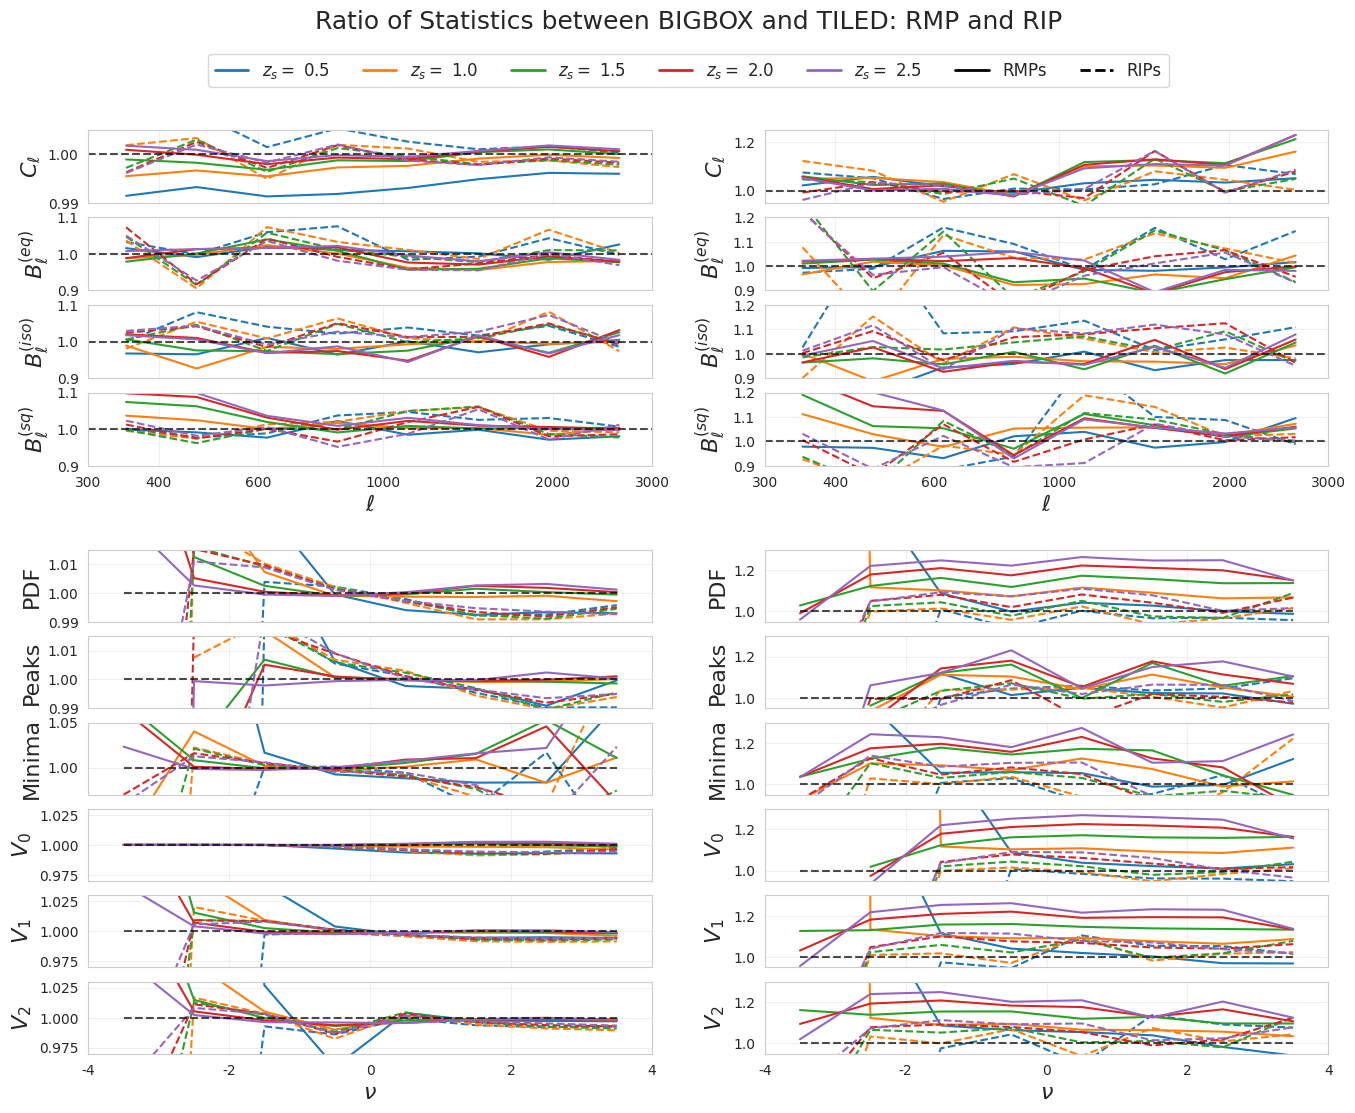

In [26]:
fig = plt.figure(figsize=(16, 12))

fig.suptitle(r"Ratio of Statistics between BIGBOX and TILED: RMP and RIP", fontsize=18, y=0.98)

# グリッドレイアウトを設定
gs_master = GridSpec(2, 2, height_ratios=[len(labels_ell), len(labels_nu)], width_ratios=[1, 1], wspace=0.2, hspace=0.2)
gs_ell_mean = GridSpecFromSubplotSpec(len(labels_ell), 1, subplot_spec=gs_master[0,0], hspace=0.2)
gs_ell_var = GridSpecFromSubplotSpec(len(labels_ell), 1, subplot_spec=gs_master[0,1], hspace=0.2)
gs_nu_mean = GridSpecFromSubplotSpec(len(labels_nu), 1, subplot_spec=gs_master[1,0], hspace=0.2)
gs_nu_var = GridSpecFromSubplotSpec(len(labels_nu), 1, subplot_spec=gs_master[1,1], hspace=0.2)

ax_ell_mean = [fig.add_subplot(gs_ell_mean[i, 0]) for i in range(len(labels_ell))]
ax_ell_var = [fig.add_subplot(gs_ell_var[i, 0]) for i in range(len(labels_ell))]
ax_nu_mean = [fig.add_subplot(gs_nu_mean[i, 0]) for i in range(len(labels_nu))]
ax_nu_var = [fig.add_subplot(gs_nu_var[i, 0]) for i in range(len(labels_nu))]

# nu-binned ratios
for i, zs_i in enumerate(zs_list):
    for j, label in enumerate(labels_nu):
        if (('bigbox', zs_i) in means_RMP and (ngal, sl) in means_RMP[('bigbox', zs_i)] and
            ('tiled', zs_i) in means_RMP and (ngal, sl) in means_RMP[('tiled', zs_i)]):
        
            if label in means_RMP[('bigbox', zs_i)][(ngal, sl)] and label in means_RMP[('tiled', zs_i)][(ngal, sl)]:
                bigbox_mean = means_RMP[('bigbox', zs_i)][(ngal, sl)][label]
                tiled_mean = means_RMP[('tiled', zs_i)][(ngal, sl)][label]
                bigbox_std = stds_RMP[('bigbox', zs_i)][(ngal, sl)][label]
                tiled_std = stds_RMP[('tiled', zs_i)][(ngal, sl)][label]
                bigbox_var = bigbox_std**2
                tiled_var = tiled_std**2
                ax_nu_mean[j].plot(nu, bigbox_mean/tiled_mean, color=colors[i])
                ax_nu_var[j].plot(nu, bigbox_var/tiled_var, color=colors[i])

        if (('bigbox', zs_i) in means_RIP and (ngal, sl) in means_RIP[('bigbox', zs_i)] and
        ('tiled', zs_i) in means_RIP and (ngal, sl) in means_RIP[('tiled', zs_i)]):
            if label in means_RIP[('bigbox', zs_i)][(ngal, sl)] and label in means_RIP[('tiled', zs_i)][(ngal, sl)]:
                bigbox_mean = means_RIP[('bigbox', zs_i)][(ngal, sl)][label]
                tiled_mean = means_RIP[('tiled', zs_i)][(ngal, sl)][label]
                bigbox_std = stds_RIP[('bigbox', zs_i)][(ngal, sl)][label]
                tiled_std = stds_RIP[('tiled', zs_i)][(ngal, sl)][(label)]
                bigbox_var = bigbox_std**2
                tiled_var = tiled_std**2
                ax_nu_mean[j].plot(nu, bigbox_mean/tiled_mean, color=colors[i], linestyle='dashed')
                ax_nu_var[j].plot(nu, bigbox_var/tiled_var, color=colors[i], linestyle='dashed')

# ell-binned ratios
for i, zs_i in enumerate(zs_list):
    for j, label in enumerate(labels_ell):
        if (('bigbox', zs_i) in means_RMP and (ngal, sl) in means_RMP[('bigbox', zs_i)] and
            ('tiled', zs_i) in means_RMP and (ngal, sl) in means_RMP[('tiled', zs_i)]):
        
            if label in means_RMP[('bigbox', zs_i)][(ngal, sl)] and label in means_RMP[('tiled', zs_i)][(ngal, sl)]:
                bigbox_mean = means_RMP[('bigbox', zs_i)][(ngal, sl)][label]
                tiled_mean = means_RMP[('tiled', zs_i)][(ngal, sl)][label]
                bigbox_std = stds_RMP[('bigbox', zs_i)][(ngal, sl)][label]
                tiled_std = stds_RMP[('tiled', zs_i)][(ngal, sl)][label]
                bigbox_var = bigbox_std**2
                tiled_var = tiled_std**2
                ax_ell_mean[j].plot(ell, bigbox_mean/tiled_mean, color=colors[i])
                ax_ell_var[j].plot(ell, bigbox_var/tiled_var, color=colors[i])

        if (('bigbox', zs_i) in means_RIP and (ngal, sl) in means_RIP[('bigbox', zs_i)] and
        ('tiled', zs_i) in means_RIP and (ngal, sl) in means_RIP[('tiled', zs_i)]):
            if label in means_RIP[('bigbox', zs_i)][(ngal, sl)] and label in means_RIP[('tiled', zs_i)][(ngal, sl)]:
                bigbox_mean = means_RIP[('bigbox', zs_i)][(ngal, sl)][label]
                tiled_mean = means_RIP[('tiled', zs_i)][(ngal, sl)][label]
                bigbox_std = stds_RIP[('bigbox', zs_i)][(ngal, sl)][label]
                tiled_std = stds_RIP[('tiled', zs_i)][(ngal, sl)][(label)]
                bigbox_var = bigbox_std**2
                tiled_var = tiled_std**2
                ax_ell_mean[j].plot(ell, bigbox_mean/tiled_mean, color=colors[i], linestyle='dashed')
                ax_ell_var[j].plot(ell, bigbox_var/tiled_var, color=colors[i], linestyle='dashed')


# nu-binned plot settings
for i, ax in enumerate(ax_nu_mean + ax_nu_var):
    ax.set_xscale("linear")
    ax.set_xlim(nu.min(), nu.max())
    ax.set_xticks([-4, -2, 0, 2, 4])
    ax.hlines(1, nu.min(), nu.max(), color="black", linestyle="--", alpha=0.7)
    ax.grid(True, alpha=0.3)
    if i == len(ax_nu_mean)-1 or i == len(ax_nu_mean) + len(ax_nu_var)-1:
        ax.set_xticklabels(["-4", "-2", "0", "2", "4"])
        ax.set_xlabel(r"$\nu$", fontsize=fontsize)
    else:
        ax.tick_params(labelbottom=False, labeltop=False, labelright=False)

# ell-binned plot settings
for i, ax in enumerate(ax_ell_mean + ax_ell_var):
    ax.set_xscale("log")
    ax.set_xlim(lmin, lmax)
    ax.set_xticks([300, 400, 600, 1000, 2000, 3000])
    ax.hlines(1, lmin, lmax, color="black", linestyle="--", alpha=0.7)
    ax.grid(True, alpha=0.3)
    if i == len(ax_ell_mean)-1 or i == len(ax_ell_mean) + len(ax_ell_var)-1:
        ax.set_xticklabels(["300", "400", "600", "1000", "2000", "3000"])
        ax.set_xlabel(r"$\ell$", fontsize=fontsize)
    else:
        ax.tick_params(labelbottom=False, labeltop=False, labelright=False)


# Common y-labels
for i, ax in enumerate(ax_nu_mean):
    ax.set_ylim(mranges_nu[i])
    ax.set_ylabel(titles_nu[i], fontsize=fontsize)
for i, ax in enumerate(ax_nu_var):
    ax.set_ylim(vranges_nu[i])
    ax.set_ylabel(titles_nu[i], fontsize=fontsize)
for i, ax in enumerate(ax_ell_mean):
    ax.set_ylim(mranges_ell[i])
    ax.set_ylabel(titles_ell[i], fontsize=fontsize)
for i, ax in enumerate(ax_ell_var):
    ax.set_ylim(vranges_ell[i])
    ax.set_ylabel(titles_ell[i], fontsize=fontsize)

custom_lines = [Line2D([0], [0], color=colors[i], lw=2) for i in range(len(zs_list))]
custom_lines2 = [Line2D([0], [0], linestyle=ls, lw=2, color="black") for ls in ["-", "--"]]

fig.legend(custom_lines + custom_lines2, [f"$z_s =$ {zs}" for zs in zs_list] + ["RMPs", "RIPs"], bbox_to_anchor=(0.5, 0.95), loc='upper center', ncol=len(zs_list) + 2, fontsize=12)

# 図を保存
fig.savefig(os.path.join(savedir, "combined_ratios_RMP_RIP.pdf"), bbox_inches="tight")
    